# AWS Notebook CityBike Model

This notebook loads a sample of the CityBike trip data, cleans it, explores it with plots, and trains a Random Forest regression model to predict trip duration.

**Important:** because trip duration is a continuous number, this is a regression task rather than a classification task. There is no single standard classification accuracy. The notebook therefore reports MAE, RMSE, and R², plus clearly defined tolerance percentages (for example, the percentage of predictions within 3 minutes of the actual duration).


## 1. Install the required libraries

This cell installs the Python packages used throughout the notebook: Matplotlib for charts, scikit-learn for machine-learning tools, pandas for working with tables, and NumPy for numerical calculations.

In [1]:
%pip install matplotlib scikit-learn pandas numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Import libraries and tools

This cell imports the libraries and functions needed to download and read the dataset, manipulate data, create visualisations, split data into training and testing sets, train a Random Forest regression model, and evaluate its predictions.

In [2]:
import os
import io
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("All libraries imported successfully!")

All libraries imported successfully!


## 3. Download the CityBike dataset

This cell checks whether the 2020 CityBike data archive is already available locally. If it is not, the archive is downloaded from Amazon S3. The cell then reports that the file is available and displays its size.

In [3]:
url = "https://s3.amazonaws.com/tripdata/2020-citibike-tripdata.zip"

annual_zip_path = "2020-citibike-tripdata.zip"

if not os.path.exists(annual_zip_path):
    print("Downloading annual dataset...")

    urllib.request.urlretrieve(
        url,
        annual_zip_path
    )

print("Dataset archive is available!")
print("File size:", round(
    os.path.getsize(annual_zip_path) / (1024 ** 2), 2
), "MB")

Dataset archive is available!
File size: 716.4 MB


## 4. Load a sample of the January 2020 data

This cell searches the annual archive for the January 2020 ZIP file, reads the CSV files inside it, and combines their records into one DataFrame. To limit memory use, it reads at most 50,000 rows per CSV and keeps no more than 100,000 rows overall. It then displays the dataset dimensions and a preview.

In [4]:
monthly_dataframes = []

with zipfile.ZipFile(annual_zip_path, "r") as annual_zip:

    # Find the January 2020 ZIP file, including files inside folders
    monthly_zip_files = [
        name for name in annual_zip.namelist()
        if name.lower().endswith(".zip")
        and "202001" in name
    ]

    print("Monthly ZIP files found:")
    for name in monthly_zip_files:
        print(name)

    if not monthly_zip_files:
        raise ValueError(
            "January 2020 ZIP was not found. "
            "Inspect annual_zip.namelist() to check the filenames."
        )

    # Open the monthly ZIP directly from the annual archive
    monthly_zip_bytes = annual_zip.read(monthly_zip_files[0])

with zipfile.ZipFile(io.BytesIO(monthly_zip_bytes), "r") as monthly_zip:

    csv_files = [
        name for name in monthly_zip.namelist()
        if name.lower().endswith(".csv")
    ]

    print("\nCSV files inside January archive:")
    for name in csv_files:
        print(name)

    if not csv_files:
        raise ValueError("No CSV files were found inside the monthly ZIP.")

    # Read up to 50,000 rows from each CSV
    for csv_name in csv_files:
        with monthly_zip.open(csv_name) as csv_file:
            part = pd.read_csv(csv_file, nrows=50_000)
            monthly_dataframes.append(part)

df = pd.concat(monthly_dataframes, ignore_index=True)

# Keep no more than 100,000 records
df = df.head(100_000).copy()

print("\nDataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Monthly ZIP files found:
2020-citibike-tripdata/202001-citibike-tripdata.zip

CSV files inside January archive:
202001-citibike-tripdata_2.csv
202001-citibike-tripdata_1.csv

Dataset loaded successfully!
Dataset shape: (100000, 13)


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,663ED5C345628B0D,classic_bike,2020-01-06 16:13:54.473,2020-01-06 16:22:30.194,Nassau Ave & Newell St,5623.03,N 6 St & Bedford Ave,5379.10,40.724813,-73.947526,40.717452,-73.958509,member
1,EB6F44388153FDEC,classic_bike,2020-01-01 03:52:44.805,2020-01-01 03:56:18.959,Grand St & Havemeyer St,5267.08,N 6 St & Bedford Ave,5379.10,40.712868,-73.956981,40.717452,-73.958509,member
2,6C6515D2135FE8ED,classic_bike,2020-01-12 15:31:50.896,2020-01-12 15:42:27.331,Dean St & Hoyt St,4446.05,Clark St & Henry St,4789.03,40.686444,-73.987591,40.697601,-73.993446,member
3,F997F715B0921283,classic_bike,2020-01-01 21:56:43.935,2020-01-01 22:00:00.103,Grand St & Havemeyer St,5267.08,N 6 St & Bedford Ave,5379.10,40.712868,-73.956981,40.717452,-73.958509,member
4,0EF25B67F55A0C71,classic_bike,2020-01-10 12:52:04.940,2020-01-10 13:00:03.199,Frost St & Meeker Ave,5371.07,N 6 St & Bedford Ave,5379.10,40.717662,-73.948800,40.717452,-73.958509,member


## 5. Inspect the raw dataset

This cell prints the number of rows and columns, lists the column names and data types, counts missing values in each column, and displays summary statistics. These checks help identify data-quality issues before cleaning.

In [5]:
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum().to_frame("Missing values"))

print("\nSummary statistics:")
display(df.describe(include="all").T)

Number of rows: 100000
Number of columns: 13

Column names:
['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']

Data types:
ride_id                object
rideable_type          object
started_at             object
ended_at               object
start_station_name     object
start_station_id      float64
end_station_name       object
end_station_id         object
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual          object
dtype: object

Missing values:


,Missing values
ride_id,0
rideable_type,0
started_at,0
ended_at,0
start_station_name,0
start_station_id,0
end_station_name,290
end_station_id,290
start_lat,0
start_lng,0



Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ride_id,100000,100000,663ED5C345628B0D,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rideable_type,100000,2,classic_bike,99972,NaN,NaN,NaN,NaN,NaN,NaN,NaN
started_at,100000,99998,2020-01-20 11:36:51.777,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ended_at,100000,99992,2020-01-08 09:23:44.471,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_station_name,100000,890,W 24 St & 7 Ave,1512,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_station_id,100000.0,NaN,NaN,NaN,5967.886635,926.958225,3460.01,5335.03,6039.06,6602.03,7886.02
end_station_name,99710,853,E 33 St & 1 Ave,4457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
end_station_id,99710,848,6197.08,4457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_lat,100000.0,NaN,NaN,NaN,40.737349,0.03116,40.6554,40.716887,40.739355,40.7568,40.818299
start_lng,100000.0,NaN,NaN,NaN,-73.980433,0.019691,-74.017134,-73.9938,-73.983293,-73.970694,-73.89795


## 6. Standardise column names

This cell removes extra spaces from column names and maps common alternative names to a consistent set of names. Standardised names make the following cleaning and feature-preparation steps more reliable.

In [6]:
# Remove accidental spaces and standardise column names
df.columns = df.columns.str.strip()

# Map common column-name variants to a standard schema
column_aliases = {
    "started_at": "starttime",
    "start_time": "starttime",
    "ended_at": "stoptime",
    "end_time": "stoptime",
    "start_lat": "start station latitude",
    "start_lng": "start station longitude",
    "start_lon": "start station longitude",
    "end_lat": "end station latitude",
    "end_lng": "end station longitude",
    "end_lon": "end station longitude",
    "member_casual": "usertype",
    "member type": "usertype",
    "trip_duration": "tripduration"
}

df = df.rename(columns={
    column: column_aliases[column]
    for column in df.columns
    if column in column_aliases
})

print("Standardised columns:")
print(df.columns.tolist())

Standardised columns:
['ride_id', 'rideable_type', 'starttime', 'stoptime', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start station latitude', 'start station longitude', 'end station latitude', 'end station longitude', 'usertype']


## 7. Clean the data and create time features

This cell checks that required timestamp and geographic columns exist, converts timestamps and coordinates to suitable data types, and creates trip duration if it is missing. It removes records with missing essential values, keeps trips between 1 minute and 2 hours, validates latitude and longitude ranges, and derives time-based features for modelling.

In [7]:
# Required geographic and timestamp columns
required_columns = [
    "starttime",
    "stoptime",
    "start station latitude",
    "start station longitude",
    "end station latitude",
    "end station longitude"
]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}\n"
        f"Available columns: {df.columns.tolist()}"
    )

# Convert timestamps to datetime
df["starttime"] = pd.to_datetime(
    df["starttime"], errors="coerce"
)

df["stoptime"] = pd.to_datetime(
    df["stoptime"], errors="coerce"
)

# Convert coordinates to numeric values
coordinate_columns = [
    "start station latitude",
    "start station longitude",
    "end station latitude",
    "end station longitude"
]

for column in coordinate_columns:
    df[column] = pd.to_numeric(
        df[column], errors="coerce"
    )

# Calculate duration if it is not provided
if "tripduration" in df.columns:
    df["tripduration"] = pd.to_numeric(
        df["tripduration"], errors="coerce"
    )
else:
    df["tripduration"] = (
        df["stoptime"] - df["starttime"]
    ).dt.total_seconds()

# Remove missing values in essential fields
df = df.dropna(
    subset=[
        "starttime",
        "stoptime",
        "tripduration"
    ] + coordinate_columns
).copy()

# Keep trips between 1 minute and 2 hours
df = df[
    df["tripduration"].between(60, 7200)
].copy()

# Validate latitude and longitude ranges
for column in [
    "start station latitude",
    "end station latitude"
]:
    df = df[df[column].between(-90, 90)]

for column in [
    "start station longitude",
    "end station longitude"
]:
    df = df[df[column].between(-180, 180)]

# Extract time-based features
df["start_hour"] = df["starttime"].dt.hour
df["day_of_week"] = df["starttime"].dt.dayofweek
df["month"] = df["starttime"].dt.month

# Add rider type if it is unavailable
if "usertype" not in df.columns:
    df["usertype"] = "Unknown"

df["usertype"] = df["usertype"].fillna("Unknown").astype(str)

print("Rows remaining after cleaning:", len(df))
print("Columns available:", df.columns.tolist())

display(df.head())

Rows remaining after cleaning: 99552
Columns available: ['ride_id', 'rideable_type', 'starttime', 'stoptime', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start station latitude', 'start station longitude', 'end station latitude', 'end station longitude', 'usertype', 'tripduration', 'start_hour', 'day_of_week', 'month']


,ride_id,rideable_type,starttime,stoptime,start_station_name,start_station_id,end_station_name,end_station_id,start station latitude,start station longitude,end station latitude,end station longitude,usertype,tripduration,start_hour,day_of_week,month
0,663ED5C345628B0D,classic_bike,2020-01-06 16:13:54.473,2020-01-06 16:22:30.194,Nassau Ave & Newell St,5623.03,N 6 St & Bedford Ave,5379.10,40.724813,-73.947526,40.717452,-73.958509,member,515.721,16,0,1
1,EB6F44388153FDEC,classic_bike,2020-01-01 03:52:44.805,2020-01-01 03:56:18.959,Grand St & Havemeyer St,5267.08,N 6 St & Bedford Ave,5379.10,40.712868,-73.956981,40.717452,-73.958509,member,214.154,3,2,1
2,6C6515D2135FE8ED,classic_bike,2020-01-12 15:31:50.896,2020-01-12 15:42:27.331,Dean St & Hoyt St,4446.05,Clark St & Henry St,4789.03,40.686444,-73.987591,40.697601,-73.993446,member,636.435,15,6,1
3,F997F715B0921283,classic_bike,2020-01-01 21:56:43.935,2020-01-01 22:00:00.103,Grand St & Havemeyer St,5267.08,N 6 St & Bedford Ave,5379.10,40.712868,-73.956981,40.717452,-73.958509,member,196.168,21,2,1
4,0EF25B67F55A0C71,classic_bike,2020-01-10 12:52:04.940,2020-01-10 13:00:03.199,Frost St & Meeker Ave,5371.07,N 6 St & Bedford Ave,5379.10,40.717662,-73.948800,40.717452,-73.958509,member,478.259,12,4,1


## Exploratory data analysis
The following charts help inspect trip duration, usage patterns, and start locations.

## 8. Explore trip patterns visually

This cell creates charts showing the distribution of trip durations, trips by hour of day, trips by day of week, trips by month, and a sample of trip starting locations. The plots help reveal patterns and provide an overview of the cleaned data.

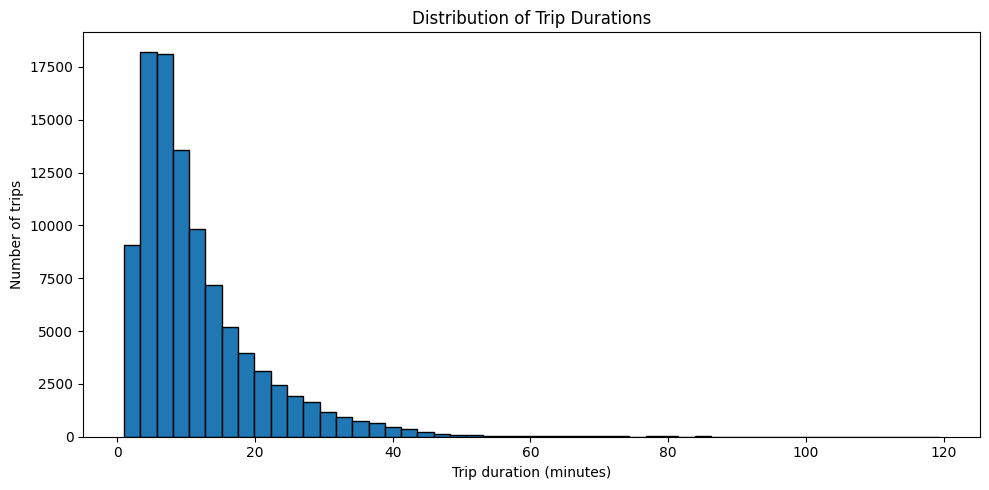

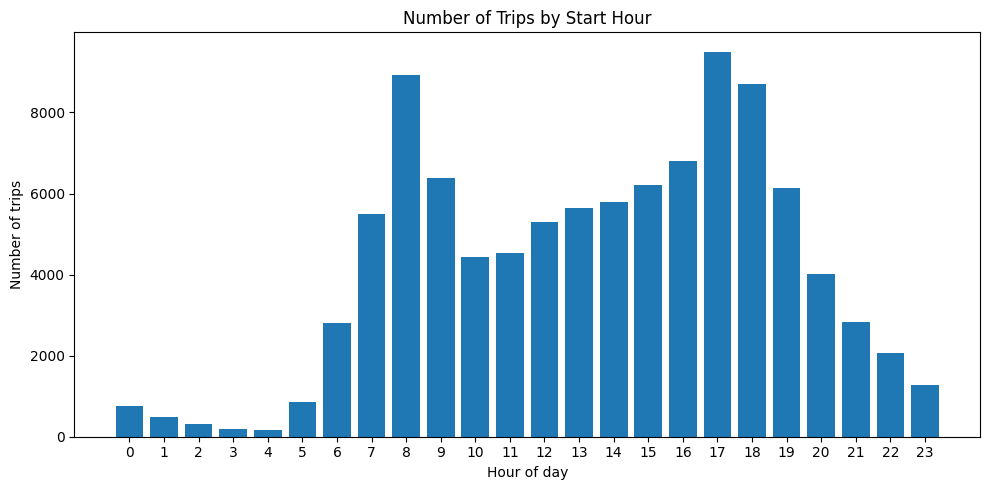

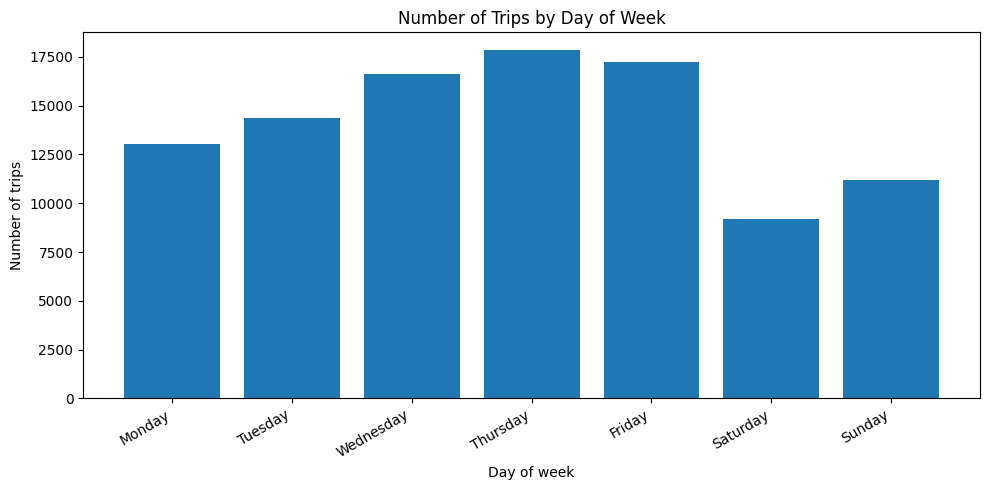

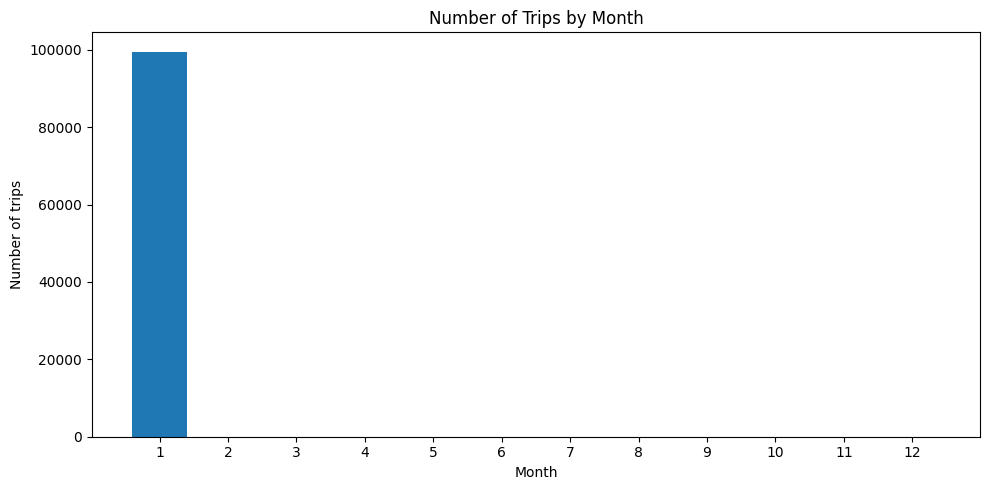

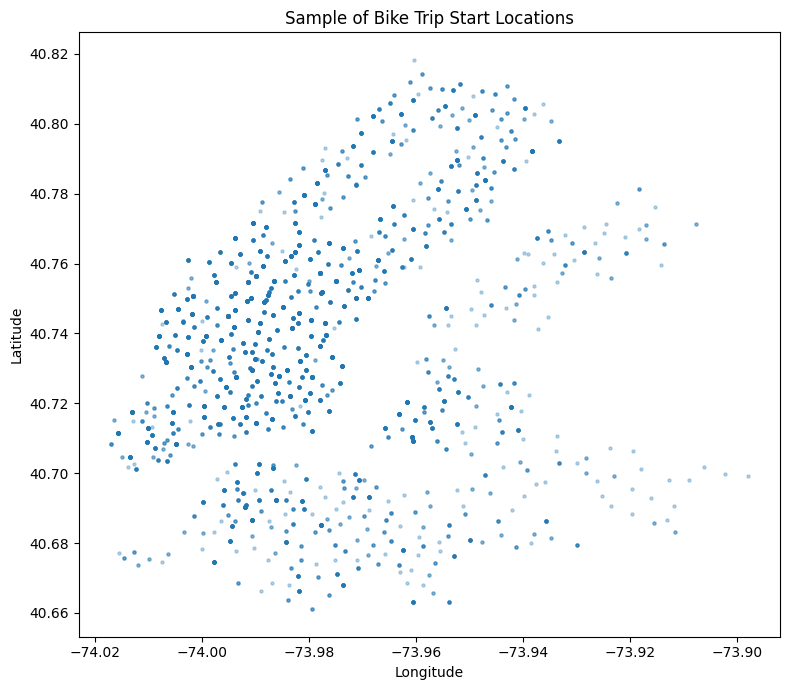

In [8]:
# Exploratory data visualisations
# These plots use the cleaned dataset.

# 1. Distribution of trip durations
plt.figure(figsize=(10, 5))
plt.hist(df["tripduration"] / 60, bins=50, edgecolor="black")
plt.xlabel("Trip duration (minutes)")
plt.ylabel("Number of trips")
plt.title("Distribution of Trip Durations")
plt.tight_layout()
plt.show()

# 2. Trips by hour of day
trips_by_hour = df.groupby("start_hour").size().reindex(range(24), fill_value=0)
plt.figure(figsize=(10, 5))
plt.bar(trips_by_hour.index, trips_by_hour.values)
plt.xticks(range(24))
plt.xlabel("Hour of day")
plt.ylabel("Number of trips")
plt.title("Number of Trips by Start Hour")
plt.tight_layout()
plt.show()

# 3. Trips by day of week
day_names = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
trips_by_day = df.groupby("day_of_week").size().reindex(range(7), fill_value=0)
plt.figure(figsize=(10, 5))
plt.bar(day_names, trips_by_day.values)
plt.xticks(rotation=30, ha="right")
plt.xlabel("Day of week")
plt.ylabel("Number of trips")
plt.title("Number of Trips by Day of Week")
plt.tight_layout()
plt.show()

# 4. Trips by month (the loaded sample may contain January only)
trips_by_month = df.groupby("month").size().reindex(range(1, 13), fill_value=0)
plt.figure(figsize=(10, 5))
plt.bar(trips_by_month.index, trips_by_month.values)
plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Number of trips")
plt.title("Number of Trips by Month")
plt.tight_layout()
plt.show()

# 5. Start locations (sampled to keep the plot readable)
map_sample = df.sample(n=min(5000, len(df)), random_state=42)
plt.figure(figsize=(8, 7))
plt.scatter(
    map_sample["start station longitude"],
    map_sample["start station latitude"],
    s=5,
    alpha=0.3
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Sample of Bike Trip Start Locations")
plt.tight_layout()
plt.show()


## 9. Prepare model features and target

This cell selects the input features—such as start time, day, month, and start/end coordinates—and uses trip duration as the target to predict. If rider type is available and has multiple categories, it is included and converted into numeric indicator columns. Finally, invalid rows are removed and the feature and target dimensions are printed.

In [9]:
features = [
    "start_hour",
    "day_of_week",
    "month",
    "start station latitude",
    "start station longitude",
    "end station latitude",
    "end station longitude"
]

# Add rider type when available
if df["usertype"].nunique() > 1:
    features.append("usertype")

target = "tripduration"

X = df[features].copy()
y = df[target].copy()

# Convert categorical rider type to numerical columns
X = pd.get_dummies(
    X,
    columns=["usertype"] if "usertype" in X.columns else [],
    dtype=int
)

# Ensure all feature values are numeric
X = X.apply(pd.to_numeric, errors="coerce")

# Remove any rows that became invalid
valid_rows = X.notna().all(axis=1) & y.notna()

X = X.loc[valid_rows].copy()
y = y.loc[valid_rows].copy()

print("Feature columns:")
print(X.columns.tolist())

print("\nFeature matrix:", X.shape)
print("Target vector:", y.shape)

Feature columns:
['start_hour', 'day_of_week', 'month', 'start station latitude', 'start station longitude', 'end station latitude', 'end station longitude', 'usertype_casual', 'usertype_member']

Feature matrix: (99552, 9)
Target vector: (99552,)


## 10. Split the data into training and test sets

This cell reserves 20% of the records for testing and uses the remaining 80% for training. A fixed random seed makes the split reproducible. The cell prints the number of records in each set.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 79641
Testing records: 19911


## 11. Tune and train the Random Forest regression model

This cell searches several Random Forest hyperparameter combinations with 3-fold cross-validation. It chooses the configuration with the lowest cross-validation mean absolute error (MAE), then keeps that best estimator as `model` for the later evaluation and prediction cells. The randomized search tests 10 combinations to balance tuning quality and runtime.

In [11]:
# Tune a Random Forest by testing several hyperparameter combinations.
# RandomizedSearchCV evaluates each sampled configuration with 3-fold cross-validation.
base_model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

param_distributions = {
    "n_estimators": [100, 150, 200],
    "max_depth": [12, 18, 24, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [2, 5, 10],
    "max_features": [1.0, "sqrt"]
}

tuning = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    n_iter=10,
    scoring="neg_mean_absolute_error",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Tuning the Random Forest model...")
tuning.fit(X_train, y_train)

model = tuning.best_estimator_

print("\nHyperparameter tuning complete!")
print("Best parameters:", tuning.best_params_)
print(f"Best cross-validation MAE: {-tuning.best_score_:.2f} seconds "
      f"({-tuning.best_score_ / 60:.2f} minutes)")


Tuning the Random Forest model...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Hyperparameter tuning complete!
Best parameters: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 1.0, 'max_depth': None}
Best cross-validation MAE: 190.86 seconds (3.18 minutes)


## 12. Evaluate the tuned model and apply an error threshold

This cell predicts trip durations for the held-out test set and calculates MAE, RMSE, and R². The configurable `threshold_seconds` value defines how close a prediction must be to count as within the chosen tolerance (default: 180 seconds, or 3 minutes). It also reports other tolerance percentages and compares the tuned Random Forest against a baseline that always predicts the training-set mean.

In [12]:
# Predict trip duration on unseen test records
y_pred = model.predict(X_test)

# Standard regression metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Regression does not have a single universal "accuracy" percentage.
# Set an explicit error threshold. A prediction is "within threshold" when
# its absolute error is no greater than this many seconds.
# Change this value to make the tolerance stricter or more lenient.
threshold_seconds = 180  # 3 minutes

actual_all = y_test.to_numpy()
absolute_errors = np.abs(actual_all - y_pred)
relative_errors = absolute_errors / np.maximum(np.abs(actual_all), 1)  # avoid division by zero

within_threshold = absolute_errors <= threshold_seconds
threshold_percentage = np.mean(within_threshold) * 100
accuracy_20_percent = np.mean(relative_errors <= 0.20) * 100
accuracy_3_minutes = np.mean(absolute_errors <= 180) * 100
accuracy_5_minutes = np.mean(absolute_errors <= 300) * 100

print("MODEL EVALUATION")
print("-" * 45)
print(f"MAE: {mae:.2f} seconds ({mae / 60:.2f} minutes)")
print(f"RMSE: {rmse:.2f} seconds ({rmse / 60:.2f} minutes)")
print(f"R² score: {r2:.4f}")
print()
print("PREDICTION TOLERANCE (accuracy-like percentages)")
print("-" * 45)
print(f"Configured threshold: +/- {threshold_seconds} seconds "
      f"({threshold_seconds / 60:.1f} minutes)")
print(f"Predictions within configured threshold: {threshold_percentage:.2f}%")
print(f"Predictions within 20% of actual duration: {accuracy_20_percent:.2f}%")
print(f"Predictions within 3 minutes of actual duration: {accuracy_3_minutes:.2f}%")
print(f"Predictions within 5 minutes of actual duration: {accuracy_5_minutes:.2f}%")

# Compare the Random Forest against a simple baseline that always predicts
# the average duration from the training set.
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_r2 = r2_score(y_test, baseline_pred)

print()
print("BASELINE COMPARISON")
print("-" * 45)
print(f"Mean-prediction baseline MAE: {baseline_mae:.2f} seconds")
print(f"Random Forest MAE:            {mae:.2f} seconds")
print(f"Mean-prediction baseline R²:  {baseline_r2:.4f}")
print(f"Random Forest R²:             {r2:.4f}")


MODEL EVALUATION
---------------------------------------------
MAE: 187.65 seconds (3.13 minutes)
RMSE: 367.55 seconds (6.13 minutes)
R² score: 0.5812

PREDICTION TOLERANCE (accuracy-like percentages)
---------------------------------------------
Configured threshold: +/- 180 seconds (3.0 minutes)
Predictions within configured threshold: 70.74%
Predictions within 20% of actual duration: 51.32%
Predictions within 3 minutes of actual duration: 70.74%
Predictions within 5 minutes of actual duration: 85.23%

BASELINE COMPARISON
---------------------------------------------
Mean-prediction baseline MAE: 398.66 seconds
Random Forest MAE:            187.65 seconds
Mean-prediction baseline R²:  -0.0001
Random Forest R²:             0.5812


## 13. Plot actual versus predicted durations

This cell randomly selects up to 1,000 test examples and plots the actual trip duration against the model prediction. The dashed diagonal represents perfect predictions; points closer to that line indicate more accurate estimates.

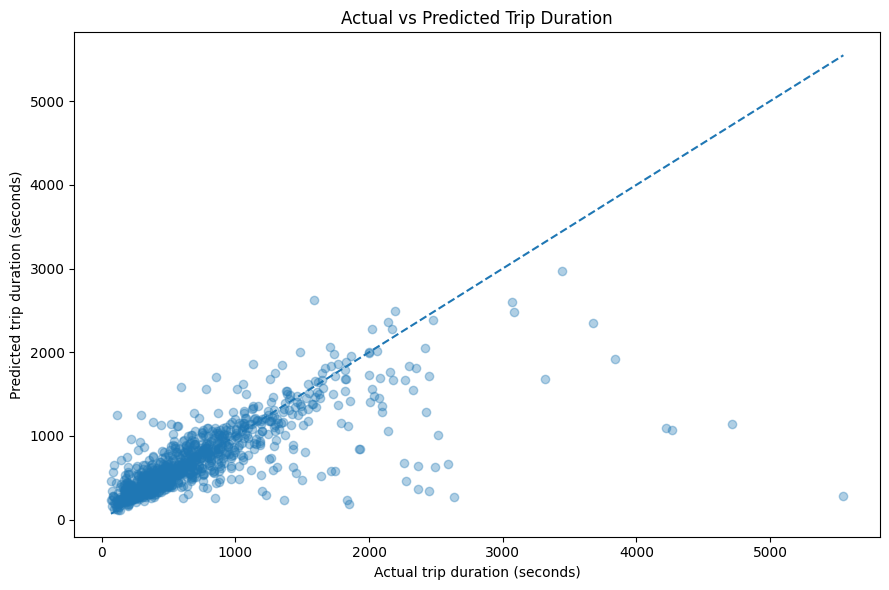

In [13]:
plot_size = min(1000, len(y_test))

rng = np.random.default_rng(42)

plot_indices = rng.choice(
    len(y_test),
    size=plot_size,
    replace=False
)

actual = y_test.iloc[plot_indices].to_numpy()
predicted = y_pred[plot_indices]

plt.figure(figsize=(9, 6))

plt.scatter(
    actual,
    predicted,
    alpha=0.35
)

minimum = min(actual.min(), predicted.min())
maximum = max(actual.max(), predicted.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual trip duration (seconds)")
plt.ylabel("Predicted trip duration (seconds)")
plt.title("Actual vs Predicted Trip Duration")

plt.tight_layout()
plt.show()

## 14. Examine feature importance

This cell retrieves the Random Forest's feature-importance scores, sorts them, plots them as a horizontal bar chart, and displays a table from most important to least important. These scores indicate which input features the model relied on most, but do not by themselves prove causation.

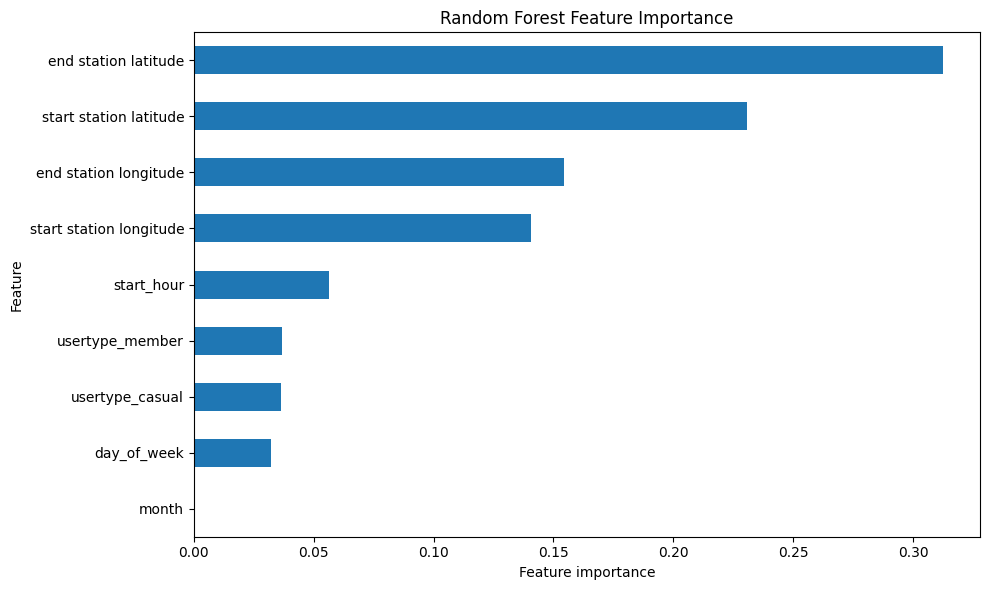

,Importance
end station latitude,0.312318
start station latitude,0.230941
end station longitude,0.154508
start station longitude,0.140651
start_hour,0.056472
usertype_member,0.036645
usertype_casual,0.036394
day_of_week,0.032071
month,0.000000


In [14]:
importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))

importance.plot(kind="barh")

plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

display(
    importance.sort_values(ascending=False).to_frame(
        name="Importance"
    )
)

## Model diagnostics
These plots show how close the predictions are to the real trip durations and how the model compares with a simple baseline.

## 15. Run additional model diagnostics

This cell creates several diagnostic plots: actual versus predicted durations, prediction residuals (actual minus predicted), and the distribution of absolute errors. It also includes tolerance-based evaluation visuals so you can inspect how often predictions fall within practical error limits.

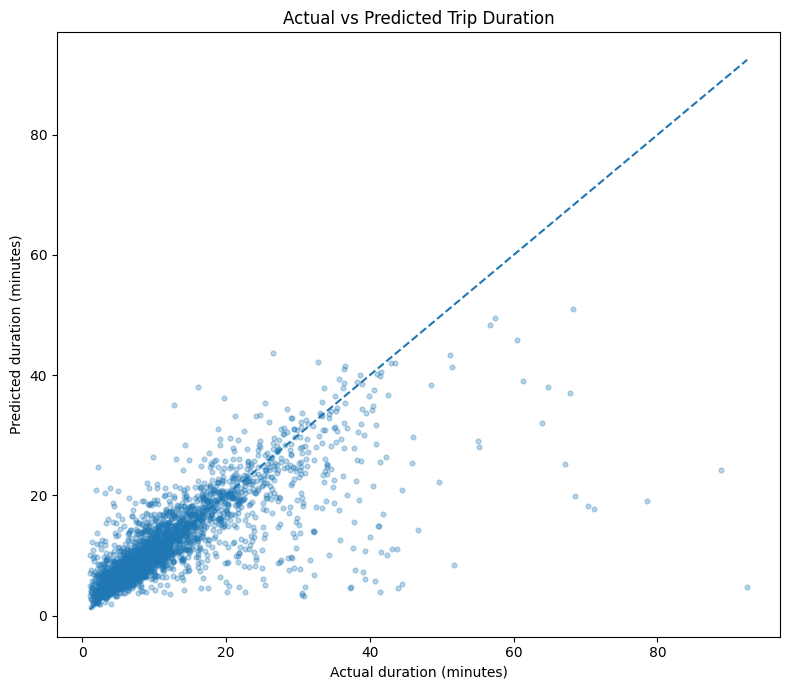

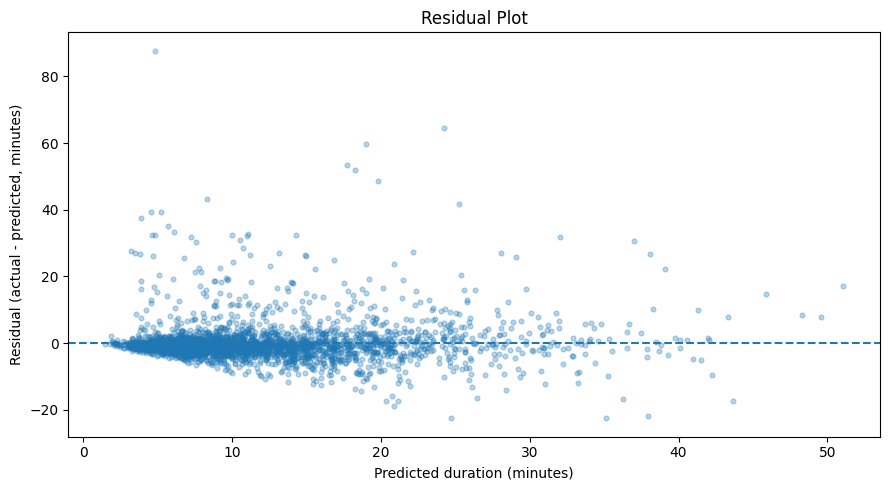

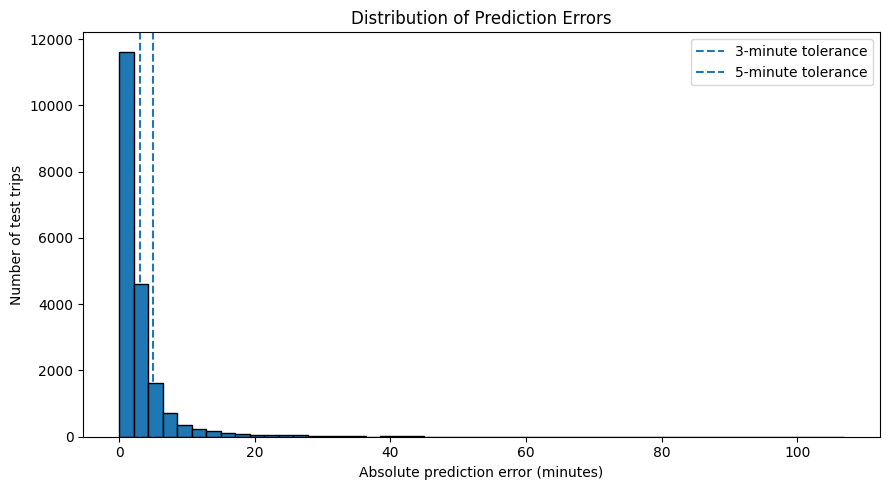

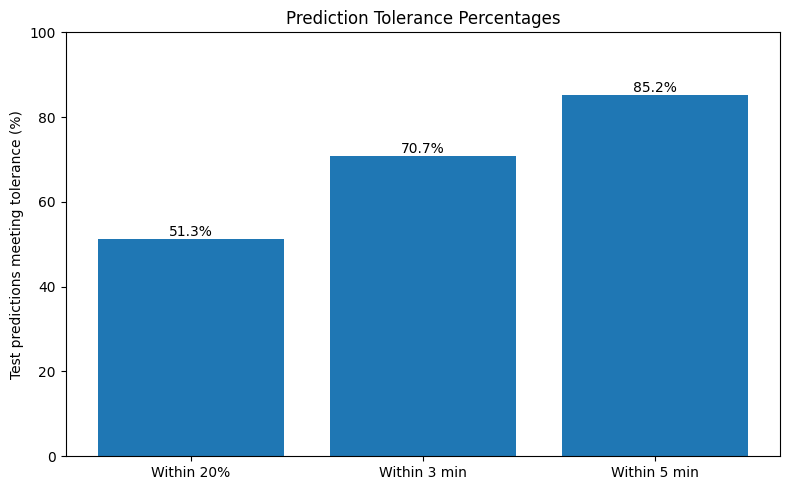

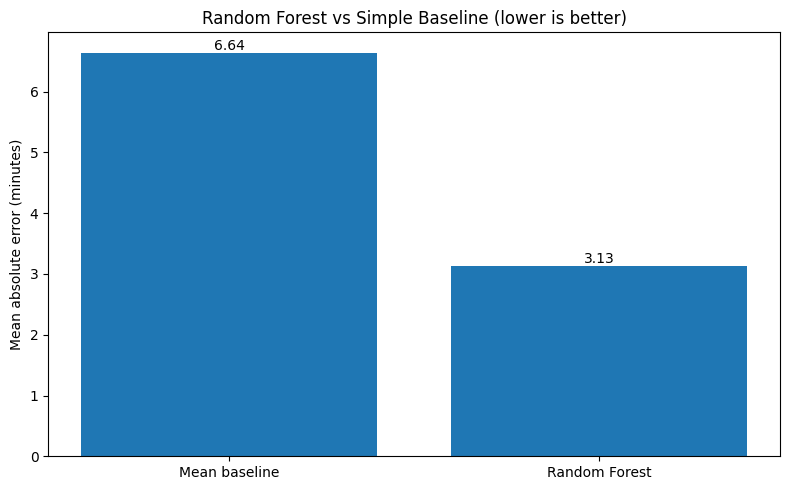

In [15]:

# Use all test predictions for error calculations and a sample for scatter plots
actual_seconds = y_test.to_numpy()
predicted_seconds_all = y_pred
residuals = actual_seconds - predicted_seconds_all

# 1. Actual vs predicted, with a reference line
plot_size = min(3000, len(actual_seconds))
rng = np.random.default_rng(42)
plot_indices = rng.choice(len(actual_seconds), size=plot_size, replace=False)
actual_sample = actual_seconds[plot_indices]
predicted_sample = predicted_seconds_all[plot_indices]

lower = min(actual_sample.min(), predicted_sample.min())
upper = max(actual_sample.max(), predicted_sample.max())

plt.figure(figsize=(8, 7))
plt.scatter(actual_sample / 60, predicted_sample / 60, alpha=0.3, s=12)
plt.plot([lower / 60, upper / 60], [lower / 60, upper / 60], linestyle="--")
plt.xlabel("Actual duration (minutes)")
plt.ylabel("Predicted duration (minutes)")
plt.title("Actual vs Predicted Trip Duration")
plt.tight_layout()
plt.show()

# 2. Residual plot: residual = actual - predicted
plt.figure(figsize=(9, 5))
plt.scatter(predicted_sample / 60, (actual_sample - predicted_sample) / 60, alpha=0.3, s=12)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted duration (minutes)")
plt.ylabel("Residual (actual - predicted, minutes)")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

# 3. Distribution of absolute prediction errors
plt.figure(figsize=(9, 5))
plt.hist(np.abs(residuals) / 60, bins=50, edgecolor="black")
plt.axvline(3, linestyle="--", label="3-minute tolerance")
plt.axvline(5, linestyle="--", label="5-minute tolerance")
plt.xlabel("Absolute prediction error (minutes)")
plt.ylabel("Number of test trips")
plt.title("Distribution of Prediction Errors")
plt.legend()
plt.tight_layout()
plt.show()

# 4. Accuracy-like tolerance percentages
tolerance_labels = ["Within 20%", "Within 3 min", "Within 5 min"]
tolerance_values = [accuracy_20_percent, accuracy_3_minutes, accuracy_5_minutes]
plt.figure(figsize=(8, 5))
bars = plt.bar(tolerance_labels, tolerance_values)
plt.ylim(0, 100)
plt.ylabel("Test predictions meeting tolerance (%)")
plt.title("Prediction Tolerance Percentages")
plt.bar_label(bars, fmt="%.1f%%")
plt.tight_layout()
plt.show()

# 5. Compare model and baseline MAE (lower is better)
plt.figure(figsize=(8, 5))
bars = plt.bar(["Mean baseline", "Random Forest"], [baseline_mae / 60, mae / 60])
plt.ylabel("Mean absolute error (minutes)")
plt.title("Random Forest vs Simple Baseline (lower is better)")
plt.bar_label(bars, fmt="%.2f")
plt.tight_layout()
plt.show()


## 16. Predict the duration of an example trip

This cell defines an example trip starting at 9 AM on a Monday in January, encodes the rider type, and aligns its columns with the features used during training. It then asks the trained model to estimate the trip duration and prints the result in seconds and minutes.

In [16]:
# Example trip: Monday at 9 AM in January
new_trip = pd.DataFrame([{
    "start_hour": 9,
    "day_of_week": 0,  # Monday = 0
    "month": 1,
    "start station latitude": 40.7410,
    "start station longitude": -73.9897,
    "end station latitude": 40.7527,
    "end station longitude": -73.9772,
    "usertype": "Subscriber"
}])

# Encode the rider type in the same way as the training data
if "usertype" in new_trip.columns:
    new_trip = pd.get_dummies(
        new_trip,
        columns=["usertype"],
        dtype=int
    )

# Match the exact training feature columns and their order
new_trip = new_trip.reindex(
    columns=X_train.columns,
    fill_value=0
)

# Generate prediction
predicted_seconds = model.predict(new_trip)[0]
predicted_minutes = predicted_seconds / 60

print("PREDICTED TRIP DURATION")
print("-" * 35)
print(f"Duration: {predicted_seconds:.0f} seconds")
print(f"Duration: {predicted_minutes:.2f} minutes")

PREDICTED TRIP DURATION
-----------------------------------
Duration: 813 seconds
Duration: 13.55 minutes


## 17. Repeat the example prediction

This cell repeats the same example-trip workflow: it prepares the input, encodes the rider type, aligns the feature columns, and predicts the duration in seconds and minutes. It can be used to confirm or demonstrate the prediction step again.

In [17]:
# Example trip: Monday at 9 AM in January
new_trip = pd.DataFrame([{
    "start_hour": 9,
    "day_of_week": 0,  # Monday = 0
    "month": 1,
    "start station latitude": 40.7410,
    "start station longitude": -73.9897,
    "end station latitude": 40.7527,
    "end station longitude": -73.9772,
    "usertype": "Subscriber"
}])

# Encode the rider type in the same way as the training data
if "usertype" in new_trip.columns:
    new_trip = pd.get_dummies(
        new_trip,
        columns=["usertype"],
        dtype=int
    )

# Match the exact training feature columns and their order
new_trip = new_trip.reindex(
    columns=X_train.columns,
    fill_value=0
)

# Generate prediction
predicted_seconds = model.predict(new_trip)[0]
predicted_minutes = predicted_seconds / 60

print("PREDICTED TRIP DURATION")
print("-" * 35)
print(f"Duration: {predicted_seconds:.0f} seconds")
print(f"Duration: {predicted_minutes:.2f} minutes")

PREDICTED TRIP DURATION
-----------------------------------
Duration: 813 seconds
Duration: 13.55 minutes


## 18. Save the trained model and feature list

This cell uses joblib to save the trained Random Forest model and the ordered list of feature columns to separate files. Saving both makes it easier to reuse the model later with inputs arranged in the correct format.

In [18]:
import joblib

joblib.dump(
    model,
    "citibike_random_forest.joblib"
)

joblib.dump(
    X_train.columns.tolist(),
    "citibike_feature_columns.joblib"
)

print("Model and feature columns saved successfully!")

Model and feature columns saved successfully!


## 19. Load the saved model and feature list

This cell loads the model and feature-column list saved in the previous step, then confirms that the model was loaded and reports how many input features it expects.

In [19]:
model = joblib.load("citibike_random_forest.joblib")

feature_columns = joblib.load(
    "citibike_feature_columns.joblib"
)

print("Saved model loaded successfully!")
print("Number of features:", len(feature_columns))

Saved model loaded successfully!
Number of features: 9


## 20. Empty code cell

This cell is currently empty and does not perform any operation. It is available if you want to add another code step.

## 21. Commented-out model-loading example

This cell contains only commented-out lines, so running it will not execute any code. It repeats the saved-model loading example and can be removed if it is no longer needed.

In [20]:
# model = joblib.load("citibike_random_forest.joblib")

# feature_columns = joblib.load(
#     "citibike_feature_columns.joblib"
# )

# print("Saved model loaded successfully!")